In [2]:
try:
    import torch  # pyright: ignore[reportMissingImports]
except ImportError:
    torch = None
    
try:
    import torch.nn as nn
except ImportError:
    torch.nn = None
import torch.nn.functional as functional
import math

In [3]:



from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-v0.1")

texte = "je résouds des équations mathématiques"
tokens = tokenizer.tokenize(texte)
print(tokens)

['▁je', '▁rés', 'oud', 's', '▁des', '▁équ', 'ations', '▁math', 'é', 'mat', 'iques']


# EMBEDDING

In [4]:
class Embedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Embedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x):
        return self.embedding(x)
VOCAB_SIZE = tokenizer.vocab_size
EMBEDDING_DIM = 768  # Dimension de l'embedding de BERT

#instanciation de la couche d'embedding
embedding_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM)

#conversion en ids
ids = tokenizer.encode(texte, return_tensors="pt")
print("ids:", ids)  # Affiche les IDs des tokens

#obtenir les vecteurs d'embeddings
vecteurs = embedding_layer(ids)
print("shape:", vecteurs.shape) 
 # Affiche la forme du tenseur d'embeddings

ids: tensor([[    1,  2218, 11310,  2456, 28713,   634, 18124,   697, 11049, 28797,
          3076,  4030]])
shape: torch.Size([1, 12, 768])


# POSITIONAL ENCODING

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, dimension, max_len=5000):
        super().__init__()
        # 1. create a matrix of zeros : shape (max_len, dimension)
        pe = torch.zeros(max_len, dimension)
        
        # 2. create position indices : [0, 1, 2, ..., max_len-1]
        position = torch.arange(0, max_len).unsqueeze(1)  # shape (max_len, 1)
        
        # 3. compute the division term using the formula
        div_term = torch.exp(torch.arange(0, dimension, 2) * (-math.log(10000.0) / dimension))
        
        # 4. fill even indices with sin, odd indices with cos
        pe[:, 0::2] = torch.sin(position * div_term)  # sin
        pe[:, 1::2] = torch.cos(position * div_term)  # cos
        
        # 5. register as buffer (not a learned parameter)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # add positional encoding to x
        # pe needs to match x's shape : x is (batch, seq_len, dim)
        return x + self.pe[:x.size(1), :].unsqueeze(0)
    
pe_layer = PositionalEncoding(512)
x = torch.zeros(1, 10, 512)
output = pe_layer(x)

print("Shape:", output.shape)           # [1, 10, 512]
print("First token :", output[0, 0, :4])   # should be non-zero
print("Second token:", output[0, 1, :4])   # should be different from first

Shape: torch.Size([1, 10, 512])
First token : tensor([0., 1., 0., 1.])
Second token: tensor([0.8415, 0.5403, 0.8219, 0.5697])


# SINGLE ATTENTION

In [6]:
class SingleHeadAttention(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        # 3 linear layers for Q, K, V (no bias needed)

        self.W_Q = nn.Linear(dimension, dimension, bias=False)
        self.W_K = nn.Linear(dimension, dimension, bias=False)
        self.W_V = nn.Linear(dimension, dimension, bias=False)

    def forward(self, x):
        # 1. compute Q, K, V from x
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # 2. compute scores : Q · Kᵀ / √d
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        
        # 3. apply softmax
        weights = torch.softmax(scores, dim=-1)
        
        # 4. weighted sum of V
        output = torch.matmul(weights, V)
        
        return output
    
attention = SingleHeadAttention(512)
x = torch.zeros(1, 10, 512)
output = attention(x)

print("Shape:", output.shape)  # should be [1, 10, 512]

Shape: torch.Size([1, 10, 512])


# MULTIHEAD ATTENTION

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dimension, num_heads):
        super().__init__()
        # dimension must be divisible by num_heads
        # each head works on dimension // num_heads
        
        self.num_heads = num_heads
        self.head_dim = dimension // num_heads
        
        self.W_Q = nn.Linear(dimension, dimension, bias=False)
        self.W_K = nn.Linear(dimension, dimension, bias=False)
        self.W_V = nn.Linear(dimension, dimension, bias=False)
        self.W_O = nn.Linear(dimension, dimension, bias=False)  # output projection

    def forward(self, x):
        batch, seq_len, dimension = x.shape
        
        # 1. compute Q, K, V
        Q = self.W_Q(x)  # [batch(for the sentence), seq_len(the number of tokens), dimension]
        K = self.W_K(x)
        V = self.W_V(x)
        
        # 2. split into num_heads
        Q = Q.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        # shape becomes [batch, num_heads, seq_len, head_dim]
        
        # 3. attention for each head (same formula as before)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(Q.size(-1))
        weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(weights, V)
        
        # 4. concatenate all heads
        output = output.transpose(1, 2).contiguous().view(batch, seq_len, dimension)
        
        # 5. final projection
        return self.W_O(output)
    
mha = MultiHeadAttention(512, 8)
x = torch.zeros(1, 10, 512)
output = mha(x)
print("Shape:", output.shape)  # should be [1, 10, 512]

Shape: torch.Size([1, 10, 512])


# FEED FORWARD

In [8]:
class FeedForward(nn.Module):
    def __init__(self, dimension, ff_dimension=2048):
        super().__init__()
        # two linear layers
        self.layer1 = nn.Linear(dimension, ff_dimension)
        self.layer2 = nn.Linear(ff_dimension, dimension)

    def forward(self, x):
        # layer1 → ReLU → layer2
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        return x
ff = FeedForward(512)
x = torch.zeros(1, 10, 512)
output = ff(x)
print("Shape:", output.shape)  # should be [1, 10, 512]

Shape: torch.Size([1, 10, 512])


# TRANSFORMER BLOCK

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, dimension, num_heads, ff_dimension=2048):
        super().__init__()
        self.attention = MultiHeadAttention(dimension, num_heads)
        self.ff = FeedForward(dimension, ff_dimension)
        self.norm1 = nn.LayerNorm(dimension)
        self.norm2 = nn.LayerNorm(dimension)

    def forward(self, x):
        # 1. attention + residual + norm
        x = self.norm1(x + self.attention(x))
        
        # 2. feedforward + residual + norm
        x = self.norm2(x + self.ff(x))
        
        return x
#on aggrandi notre dimension jusqu a 2048 pour relu puis on revient à 512 pour la sortie du block
block = TransformerBlock(512, 8)
x = torch.zeros(1, 10, 512)
output = block(x)
print("Shape:", output.shape)  # should be [1, 10, 512]

Shape: torch.Size([1, 10, 512])


# MINI TRANSFORMER

In [10]:
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, dimension, num_heads, num_layers, ff_dimension=2048, max_len=5000):
        super().__init__()
        self.embedding = Embedding(vocab_size, dimension)
        self.positional_encoding = PositionalEncoding(dimension, max_len)
        self.blocks = nn.ModuleList([
            TransformerBlock(dimension, num_heads, ff_dimension)
            for _ in range(num_layers)
        ])
        self.linear = nn.Linear(dimension, vocab_size)

    def forward(self, x):
        # 1. embedding + positional encoding
        x = self.embedding(x)
        x = self.positional_encoding(x)
        
        # 2. pass through N transformer blocks
        for block in self.blocks:
            x = block(x)
        
        # 3. project to vocabulary size
        x = self.linear(x)
        
        return x
model = MiniTransformer(
    vocab_size=tokenizer.vocab_size,  # ~32000
    dimension=512,
    num_heads=8,
    num_layers=6
)

ids = tokenizer.encode("je résous des équations mathématiques", return_tensors="pt")
output = model(ids)
print("Shape:", output.shape)  # should be [1, nb_tokens, 32000]

Shape: torch.Size([1, 11, 32000])


# TEST


In [11]:
# Simple training loop on a few examples
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Toy example : model tries to predict next token
ids = tokenizer.encode("je résous des équations mathématiques", return_tensors="pt")

for epoch in range(100):
    optimizer.zero_grad()
    
    output = model(ids[:, :-1])  # input : all tokens except last
    target = ids[:, 1:]          # target : all tokens except first
    
    loss = criterion(output.view(-1, tokenizer.vocab_size), target.view(-1))
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 10.6749
Epoch 10, Loss: 0.4745
Epoch 20, Loss: 0.0808
Epoch 30, Loss: 0.0479
Epoch 40, Loss: 0.0373
Epoch 50, Loss: 0.0319
Epoch 60, Loss: 0.0285
Epoch 70, Loss: 0.0261
Epoch 80, Loss: 0.0241
Epoch 90, Loss: 0.0224


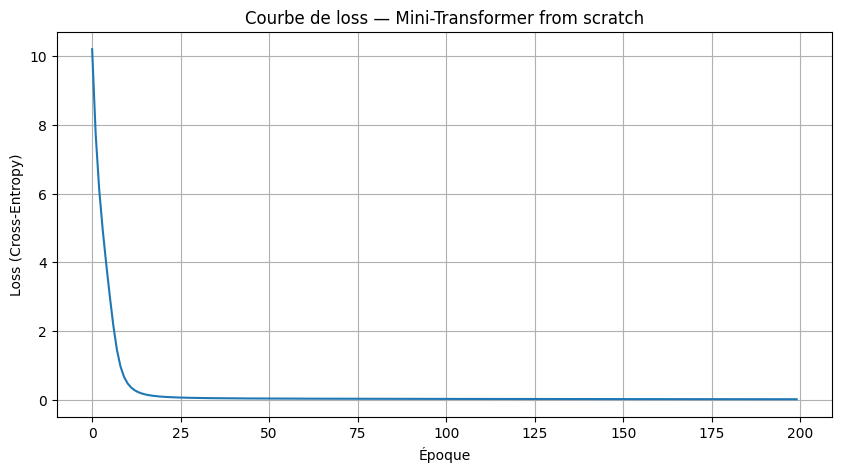

In [12]:
import matplotlib.pyplot as plt

losses = []
model = MiniTransformer(
    vocab_size=tokenizer.vocab_size,
    dimension=512,
    num_heads=8,
    num_layers=6
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

ids = tokenizer.encode("je résous des équations mathématiques", return_tensors="pt")

for epoch in range(200):
    optimizer.zero_grad()
    output = model(ids[:, :-1])
    target = ids[:, 1:]
    loss = criterion(output.view(-1, tokenizer.vocab_size), target.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Courbe de loss — Mini-Transformer from scratch")
plt.xlabel("Époque")
plt.ylabel("Loss (Cross-Entropy)")
plt.grid(True)
plt.savefig("loss_mini_transformer.png", dpi=150, bbox_inches='tight')
plt.show()

Mini-Transformer — paramètres entraînables : 51,702,016
Mistral-7B total — paramètres : 7,248,547,840
Mistral LoRA     — paramètres entraînés  : 6,815,744
Ratio LoRA/Total : 0.094%


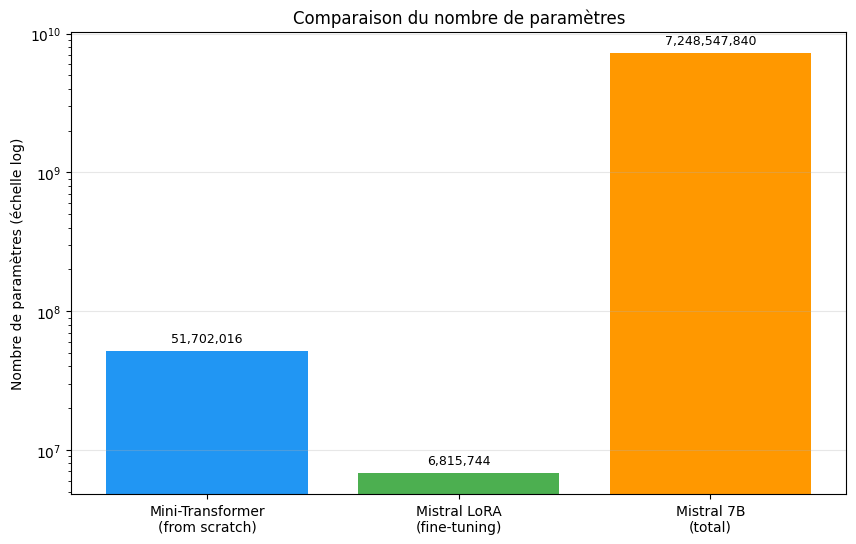

In [13]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

mini_params = count_parameters(model)

print(f"Mini-Transformer — paramètres entraînables : {mini_params:,}")
print(f"Mistral-7B total — paramètres : 7,248,547,840")
print(f"Mistral LoRA     — paramètres entraînés  : 6,815,744")
print(f"Ratio LoRA/Total : {6815744/7248547840*100:.3f}%")

# Graphique comparatif
labels = ['Mini-Transformer\n(from scratch)', 'Mistral LoRA\n(fine-tuning)', 'Mistral 7B\n(total)']
values = [mini_params, 6815744, 7248547840]
colors = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.yscale('log')
plt.title("Comparaison du nombre de paramètres")
plt.ylabel("Nombre de paramètres (échelle log)")
plt.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.1,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.savefig("comparaison_parametres.png", dpi=150, bbox_inches='tight')
plt.show()